In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

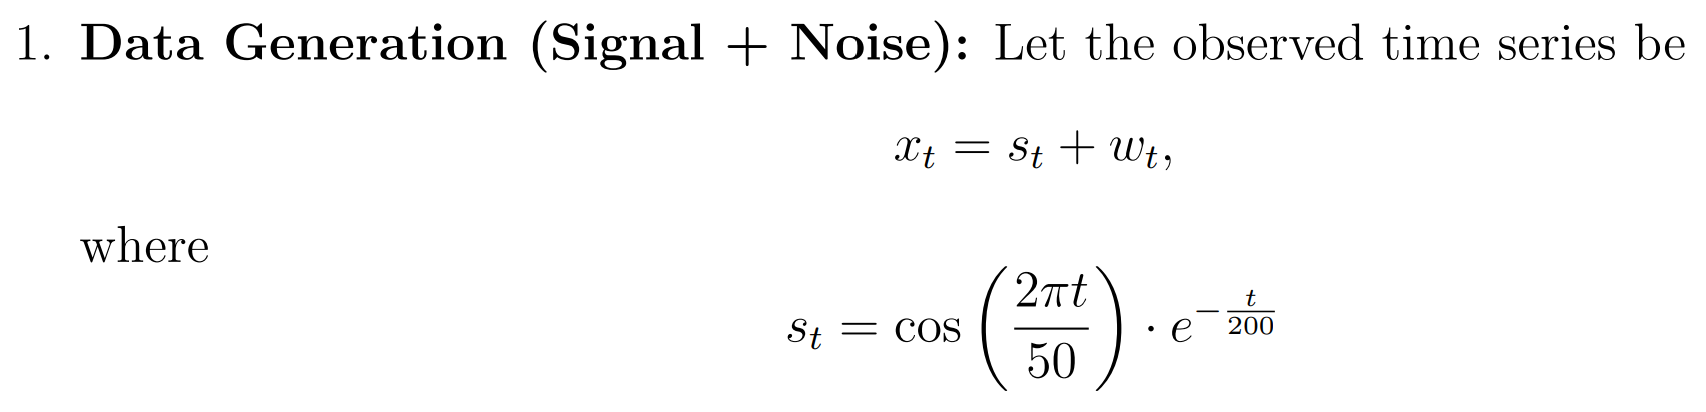

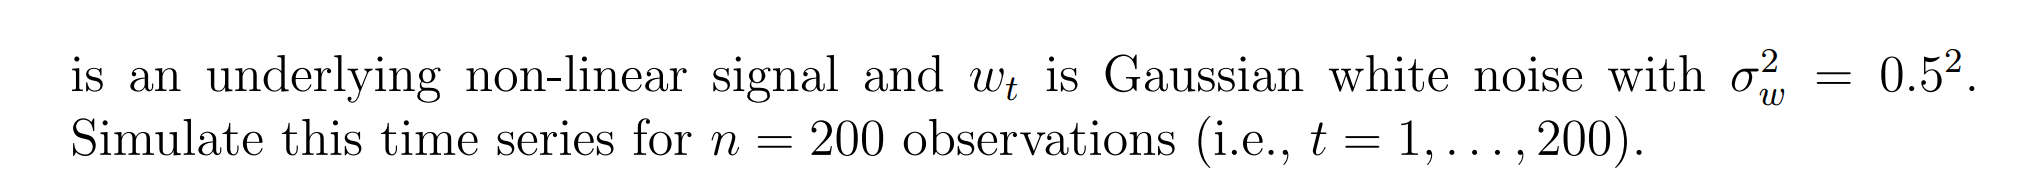

In [2]:
varW = 0.5**2
n = 200
wt = np.random.normal(scale = np.sqrt(varW),size = n)
tIndex = np.arange(1,201,1)
st=np.cos(2*np.pi*tIndex/50) * np.exp(-tIndex/200)
xt = st + wt
xt

array([ 3.35078140e-01,  6.44776275e-01,  1.08168324e+00,  4.21528925e-01,
        7.80271616e-01,  1.67367458e+00,  1.21010066e+00,  9.57532851e-01,
        1.08617884e+00,  8.48678903e-02,  9.19861417e-01, -1.89985556e-01,
       -6.65305064e-01,  2.71628780e-01, -5.18054833e-01, -5.88909537e-01,
       -5.73701618e-01,  3.45277802e-01, -3.06548618e-01, -1.53207477e+00,
       -9.82488012e-01, -9.62846626e-01, -7.44869009e-01, -1.17566646e+00,
       -4.71600833e-01, -1.76016774e+00, -1.86483549e-01, -2.02963411e-01,
       -3.67399920e-01, -7.62025822e-01, -7.16351746e-02, -7.90726105e-01,
       -5.19260782e-01,  5.57511794e-01, -6.95773062e-01, -6.87557981e-02,
        3.50547478e-01,  4.93419479e-01,  1.00229394e+00,  1.02213207e-02,
        7.25505633e-01,  1.07644853e+00, -4.74471210e-01,  4.98285752e-01,
       -7.27574468e-02,  3.67761735e-01,  1.01918825e+00, -2.20338392e-01,
        3.06841511e-01,  3.17794641e-01,  1.27635898e-01, -4.28341323e-01,
        5.17389242e-01,  

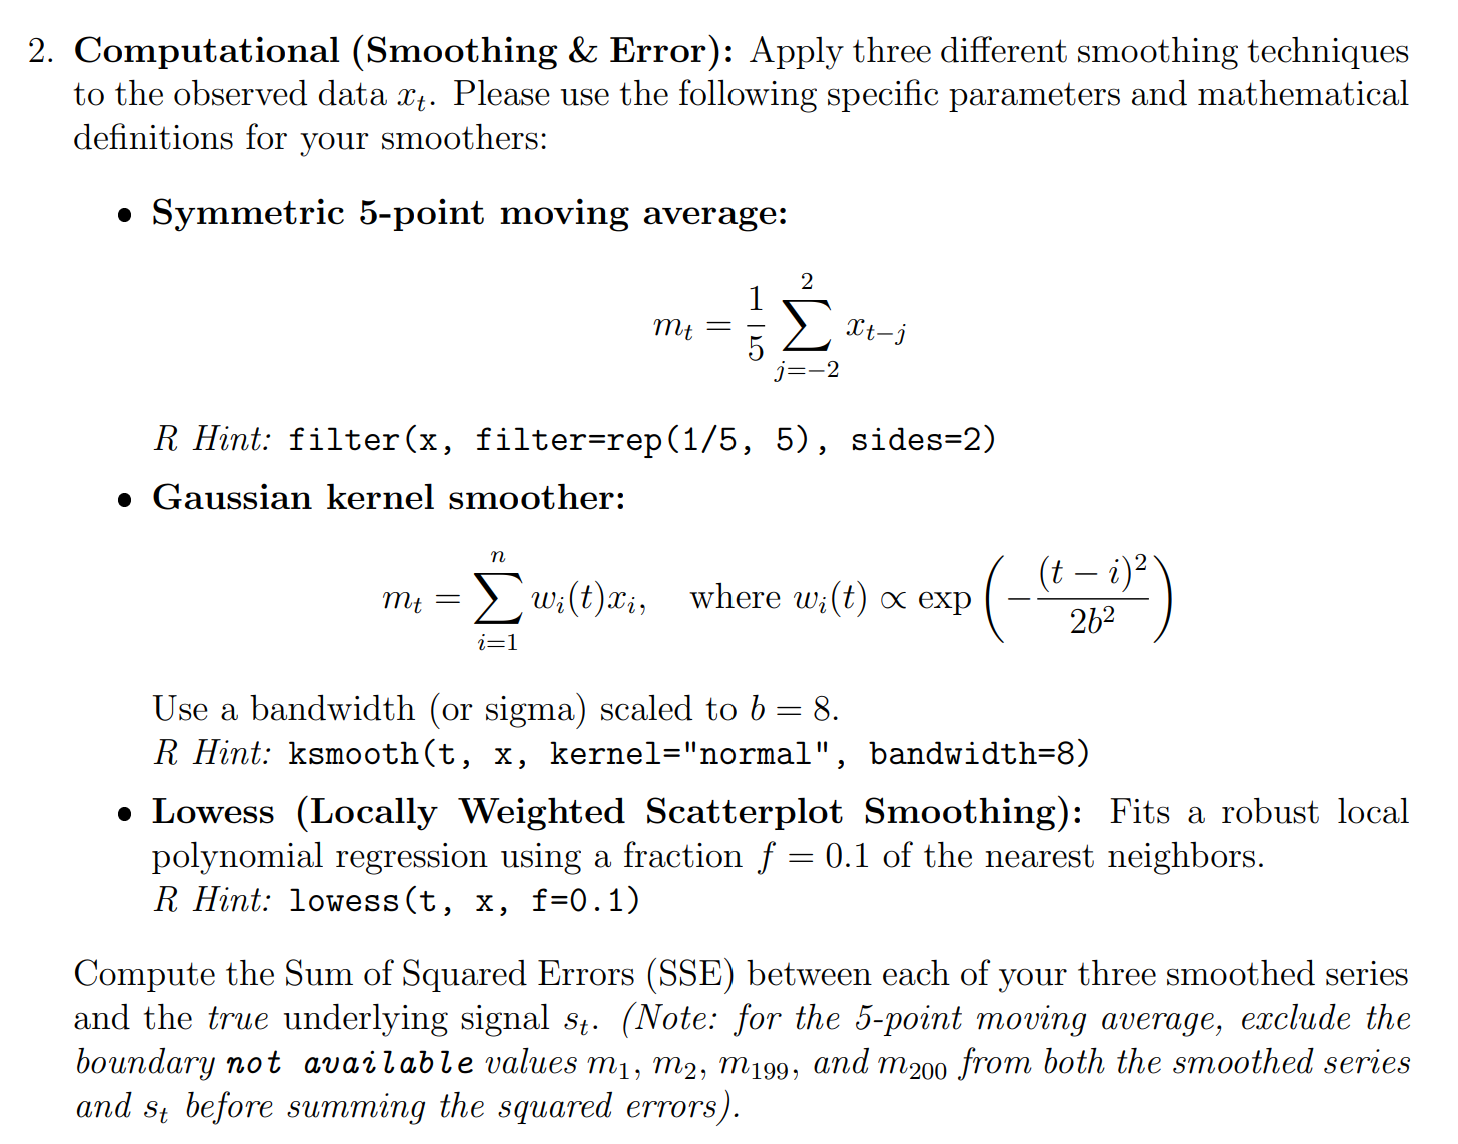

In [3]:
from statsmodels.tsa.filters.filtertools import convolution_filter
maWeights = [0.2, 0.2, 0.2, 0.2, 0.2]
maT = convolution_filter(xt, maWeights, nsides=2)
kr = sm.nonparametric.KernelReg(
    endog=xt, exog=tIndex, var_type="c", reg_type='lc', bw=[8])
krT, _ = kr.fit()
lowessT = sm.nonparametric.lowess(
   xt, tIndex, frac=0.1, return_sorted=False)
smoothed = [maT, krT, lowessT]
SSEs = []
for smoothedSet in smoothed:
    SSEs.append(float(np.nansum((smoothedSet-st)**2)))
smoothedSeries = ["Moving Average", "Kernel Smoothing", "Lowess"]
print(f"The total SSE for the {smoothedSeries[0]} series is {SSEs[0]}")
print(f"The total SSE for the {smoothedSeries[1]} series is {SSEs[1]}")
print(f"The total SSE for the {smoothedSeries[2]} series is {SSEs[2]}")

The total SSE for the Moving Average series is 12.02178395754461
The total SSE for the Kernel Smoothing series is 12.855568286994332
The total SSE for the Lowess series is 7.315091867170072


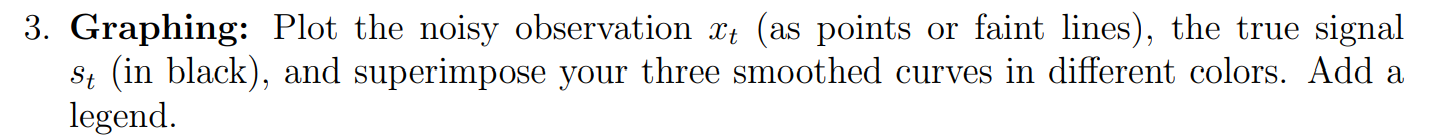

<Axes: >

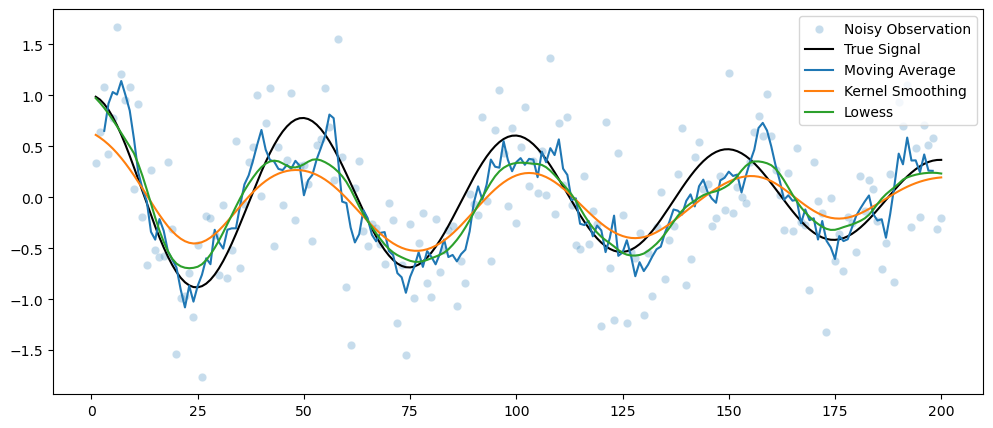

In [4]:
plt.figure(figsize=(12,5))
sns.scatterplot(x=tIndex, y=xt, alpha = 0.25, label = "Noisy Observation")
sns.lineplot(x=tIndex, y= st, color = 'black', label="True Signal")
sns.lineplot(x=tIndex, y=maT , label="Moving Average")
sns.lineplot(x=tIndex, y=krT , label="Kernel Smoothing")
sns.lineplot(x=tIndex, y=lowessT , label="Lowess")

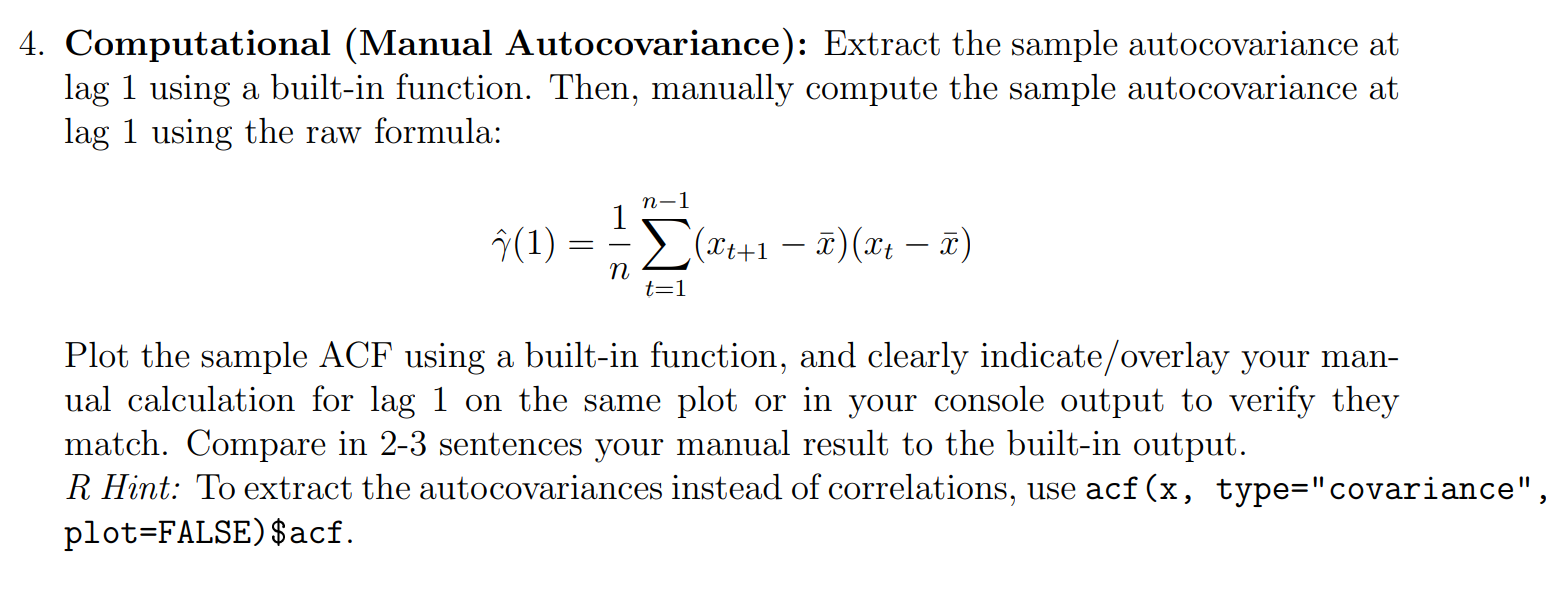

In [5]:
from statsmodels.tsa.stattools import acovf
acovf1 = acovf(xt, nlag=1)
print(f"Built-in Function Lag 1 value: {acovf1[1]:.2f}")

Built-in Function Lag 1 value: 0.16


In [6]:
xbar = np.mean(xt)
lag1sum = np.sum((xt[1:] - xbar) * (xt[:-1] - xbar))
ac1manual = lag1sum * 1/n
print(f"Manual Lag 1 value: {ac1manual:.2f}")

Manual Lag 1 value: 0.16


The two results are identical. Both use biased estimator (n) vs. unbiased estimator (n-k)

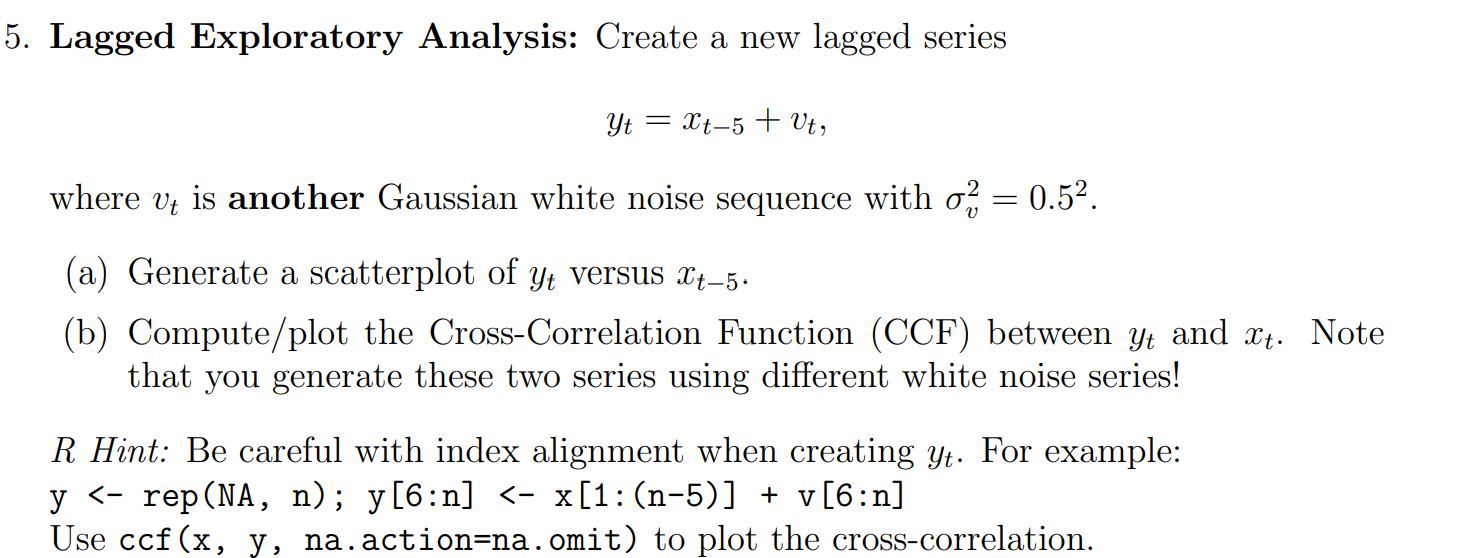

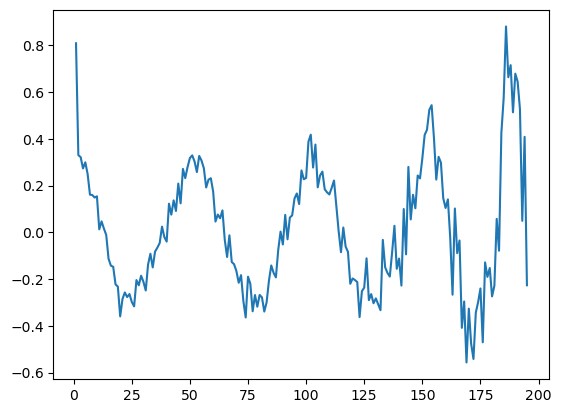

In [7]:
vt = np.random.normal(scale=0.5, size=195)
yt = xt[:-5] + vt
from statsmodels.tsa.stattools import ccf
ccf = ccf(xt[:-5], yt)
sns.lineplot(x=tIndex[:-5], y=ccf)
topindices = np.argsort(ccf)[-20:][::-1]

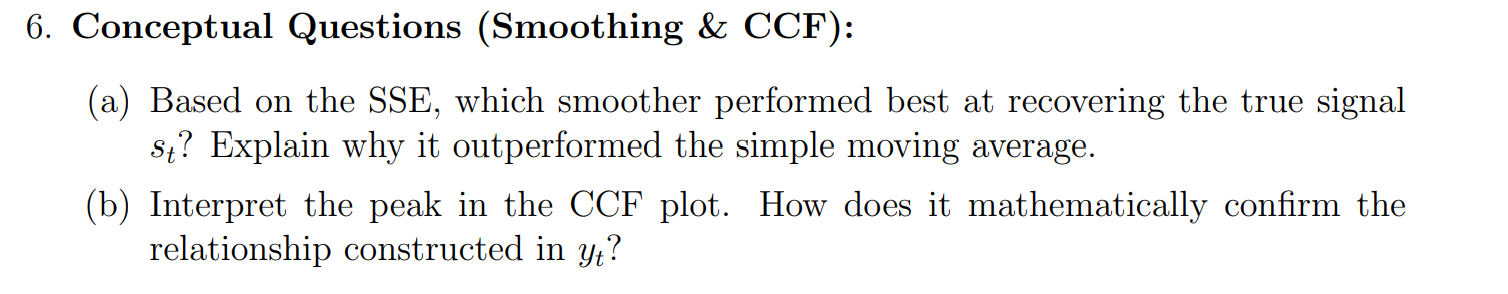

(A) Based purely on SSE, the Lowess performed best at recovering the true signal st from the noisy observations xt. It likely outperformed for two reasons: 1) Lowess performs much better in boundary cases than moving averages and kernel smoothing so the error in the edge cases is reduced. Also Lowess is much more robust in eliminating sudden shocks from white noise, which is exactly what we want when we are trying to recover the true signal.

(B) The CCF plot peaks around every 50th interval (assuming the end of the plot is invalid due to a value higher than 1). A closer look shows that the peaks are usually around 104, 55, essentially lining up exactly with our lag 5, as expected since the original series peaks every 50.

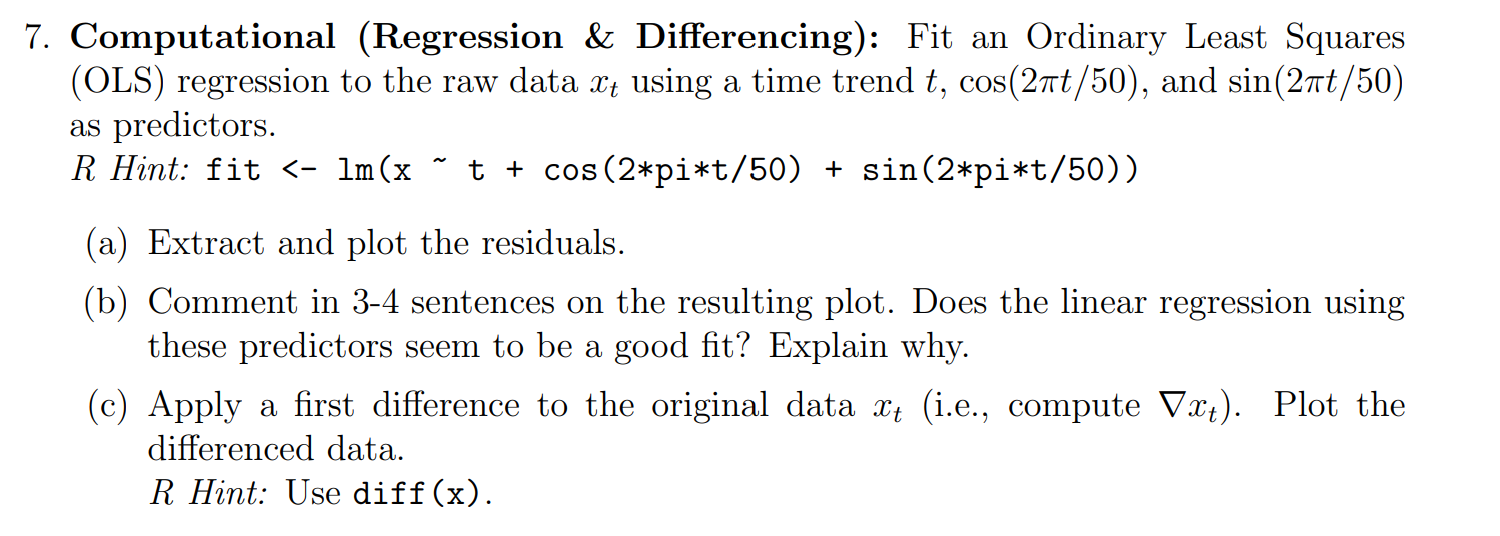

In [8]:
cos = np.cos(2*np.pi*tIndex/50)
sin = np.sin(2*np.pi*tIndex/50)
df = pd.DataFrame({
    'tIndex': tIndex,
    'Sin': sin,
    'Cos': cos
})
X = sm.add_constant(df)
y = xt
ols = sm.OLS(y, X).fit()

Text(0, 0.5, 'Residuals')

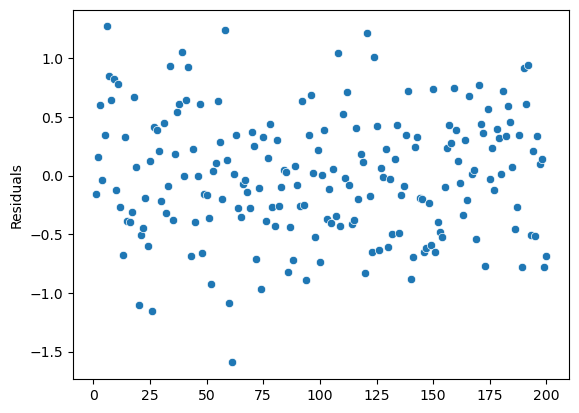

In [9]:
residuals = ols.resid
sns.scatterplot(x=tIndex, y=residuals)
plt.ylabel('Residuals')

The errors are randomly distributed on the plot. They follow the desired 'cloud' shape. Although no attestation can be made to the model's ability to fit past data or predict new data, the model structure does not appear to violate any linear regression assumptions such as heteroskedascity, linearity, and independence of errors.

Text(0, 0.5, 'Differenced xT')

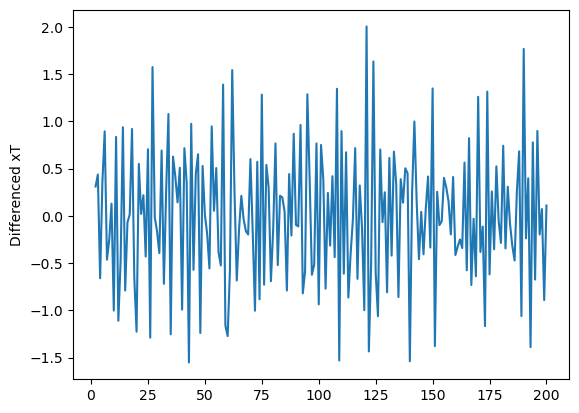

In [10]:
xtDifference = np.diff(xt)
tIndexDiff = tIndex[1:]
sns.lineplot(x=tIndexDiff, y=xtDifference)
plt.ylabel("Differenced xT")